In [16]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [4]:
data = load_breast_cancer()
x = data.data
y = data.target

scalar = StandardScaler()
x_scaled = scalar.fit_transform(x)
kmeans = KMeans(n_clusters=2,random_state=42)
y_kmeans = kmeans.fit_predict(x_scaled)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [9]:
print(f"Accuracy: {accuracy_score(y,y_kmeans)*100:.2f}%")
print(f"classification_report: {classification_report(y,y_kmeans)}")
print(f"confusion_matrix: {confusion_matrix(y,y_kmeans)}")

Accuracy: 91.21%
classification_report:               precision    recall  f1-score   support

           0       0.93      0.83      0.88       212
           1       0.90      0.96      0.93       357

    accuracy                           0.91       569
   macro avg       0.92      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569

confusion_matrix: [[175  37]
 [ 13 344]]


In [18]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
# df = pd.DataFrame(x)
# df['cluster'] = y_kmeans
# df['true label'] = y

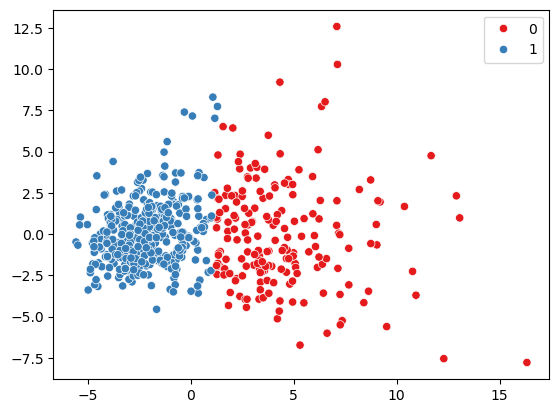

In [19]:
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=y_kmeans,palette='Set1')
plt.show()

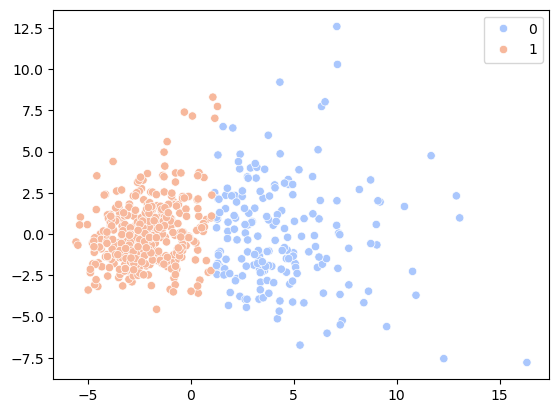

In [20]:
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=y_kmeans,palette='coolwarm')
plt.show()

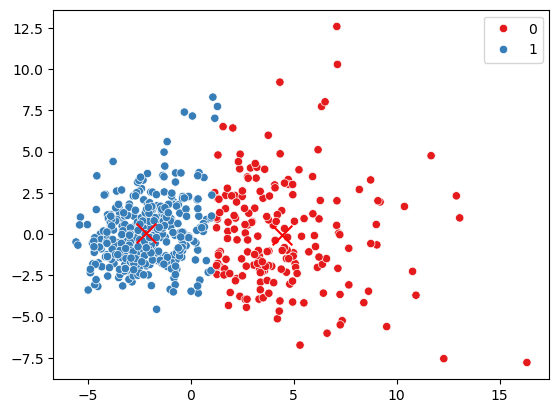

In [21]:
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],hue=y_kmeans,palette='Set1')
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0],centers[:,1],s=200,c='red',marker='x',label="centroids")
plt.show()